In [1]:
import numpy as np
from matplotlib import pyplot as plt
import gradio as gr
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from PIL import Image
import io
from matplotlib import rcParams
rcParams["font.family"] = "Times New Roman"
rcParams["font.size"] = 12
rcParams["axes.spines.top"] =  False
rcParams["axes.spines.right"] = False
from neuron_models import MorrisLecarModel, run_morrislecar_simulation, launch_morrislecar_app

## Run simulation

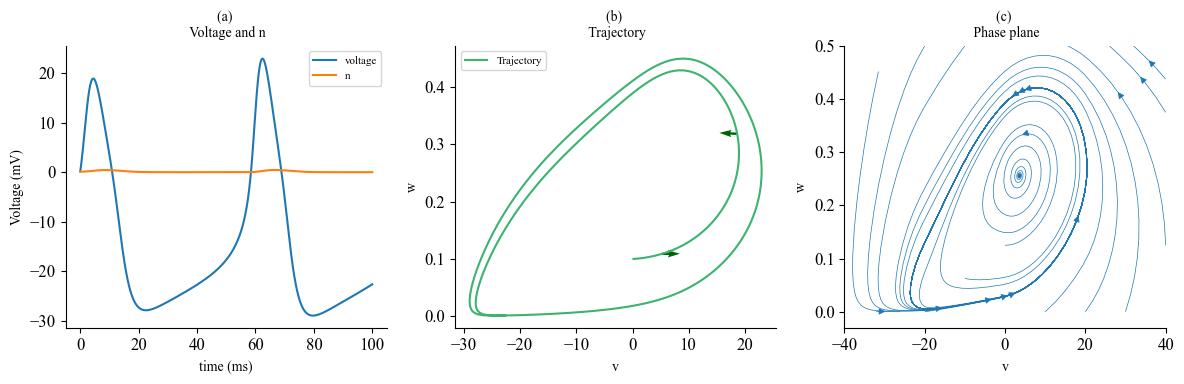

In [3]:
# Parameters
v0 = 0.1
n0 = 0.1
I_ext = 40
model = MorrisLecarModel(I_ext = I_ext)

# Solving ODE
t = np.arange(0,100,0.01)
v_time, n_time, dv, dn = model.solve( v0 = v0, n0 = n0, dt = 0.01, iter = 10000)

# Plotting
plt.figure(figsize = (12,4))

plt.subplot(1,3,1)
plt.title('(a) \n Voltage and n', fontsize = 10)
plt.xlabel('time (ms)', fontsize = 10)
plt.ylabel('Voltage (mV)', fontsize = 10)
plt.plot(t,v_time, label = 'voltage')
plt.plot(t,n_time, label = 'n')
plt.legend(fontsize = 8)

# Nullclines
plt.subplot(1,3,2)
plt.plot(v_time,
         n_time,
         linestyle="-",
         label = 'Trajectory',
         color = 'mediumseagreen')

plt.quiver(v_time[100],
           n_time[100],
           dv[100], dn[100], color = 'darkgreen')
          #  headwidth = 9,
          #  headlength = 7,
          #  color = 'darkgreen',
          #  scale = 4)

plt.quiver(v_time[500],
           n_time[500],
           dv[500], dn[500], color = 'darkgreen')
          #  headwidth = 9,
          #  headlength = 7,
          #  color = 'darkgreen',
          #  scale = 3)

plt.legend(fontsize = 8)
plt.title('(b) \n Trajectory' ,fontsize = 10)
plt.xlabel('v', fontsize = 10)
plt.ylabel('w', fontsize = 10)


# Phase plot
plt.subplot(1,3,3)
# startpoints = None
# density = 0.3
# v_0 = np.linspace(-40, 40, 5)
# n_0 = np.linspace(0, 0.5, 5)
# model.phaseplot(v0, n0, startpoints, density)
v_0 = np.linspace(-40, 40, 5)
n_0 = np.linspace(0, 0.5, 5)
startpoints = None
model.phaseplot(v_0, n_0,startpoints , 0.3)
plt.title('(c) \n Phase plane' ,fontsize = 10)
plt.xlabel('v', fontsize = 10)
plt.ylabel('w', fontsize = 10)

plt.tight_layout()
plt.show()


In [4]:
launch_morrislecar_app()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
